In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Dataset 1 UVA.csv", sep=";")

In [3]:
df.head


<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m         0-0-0      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v         0-0-0      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m         0-0-0      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v         0-0-0      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m         0-0-0      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [4]:
df['geboortedatum'] = df['geboortedatum'].replace(
    ['0', '0-0-0', '0000-00-00'],
    pd.NA
)

In [5]:
df['geboortedatum'].isna().mean() * 100

39.96

In [6]:
df.head

<bound method NDFrame.head of                              id geslacht geboortedatum postcode woonplaats  \
0      5cb9a38136dd1336b9c528d1        m          <NA>      NaN        NaN   
1      5cb9a38336dd1336b9c537f3        v          <NA>      NaN        NaN   
2      5cb9a38236dd1336b9c52f07        m          <NA>      NaN        NaN   
3      5cb9a38236dd1336b9c53694        v          <NA>      NaN        NaN   
4      5cb9a38636dd1336b9c54e48        m          <NA>      NaN        NaN   
...                         ...      ...           ...      ...        ...   
19995  5c6bed6d5798a7942837bfcd        m    19-09-1947  3815 MN        NaN   
19996  5c6bed715798a7942837dbb0        m    07-09-1986  7553 lg        NaN   
19997  5c6bed725798a7942837e588        m           NaN   2412vf        NaN   
19998  5c6bed6b5798a7942837b3c3        m    15-03-1945  5632 PM        NaN   
19999  5c6bed715798a7942837dd89        v    27-03-1997  6721 GV        NaN   

                                 

In [7]:
df = df.rename(columns={
    'geslacht': 'gender',
    'geboortedatum': 'birth_date',
    'postcode': 'postcode',
    'woonplaats': 'city',
    'interesses': 'interests'
})

Gender analysis

In [8]:
df['gender'].value_counts(dropna=False)

gender
v          11018
m           8493
o            409
Mevrouw       57
De Heer       23
Name: count, dtype: int64

In [9]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'v': 'female',
    'mevrouw': 'female',
    'm': 'male',
    'de heer': 'male',
    'o': 'other'
})

In [10]:
df['gender'].value_counts(dropna=False)

gender
female    11075
male       8516
other       409
Name: count, dtype: int64

In [11]:
df['gender'].value_counts(normalize=True)

gender
female    0.55375
male      0.42580
other     0.02045
Name: proportion, dtype: float64

In [12]:
from datetime import datetime

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
today = pd.to_datetime('today')

df['age'] = (today - df['birth_date']).dt.days // 365

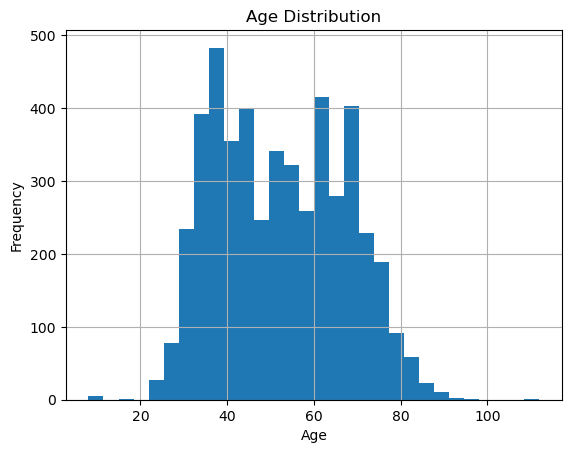

In [13]:
import matplotlib.pyplot as plt

df['age'].dropna().hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [14]:
df_interests = df.copy()

df_interests['interests'] = df_interests['interests'].str.split(',')
df_interests = df_interests.explode('interests')

In [15]:
df_interests['interests'] = (
    df_interests['interests']
    .str.strip()
    .str.lower()
)

Unique interests

In [16]:
df_interests['interests'].nunique()

60

In [17]:
df_interests['interests'].unique()

array(['energie', 'loterij', 'kranten', 'entertainment', 'winactie',
       'cadeau', 'bladen', 'kansspelen', 'goededoelen', 'acties',
       'unknown', 'kortingen', 'onderzoek', 'auto', 'cx80', 'mkb',
       'verzekering', 'auto inruilen', 'mazda', 'elektrisch',
       'zakelijk rijden', 'audi', 'mazda6e', 'ondernemers', 'dacia',
       'bigevent', 'hybrid', 'mercedes', 'toyota', 'lease', 'windows',
       'bank', 'beleggen', 'finance', 'cx60', 'hr', 'cx5', 'bedrijven',
       'it', 'telcom', 'hypotheek', 'centraal beheer', 'mx30', 'cx30',
       'ios', 'android', 'hyundai', 'linux', nan, 'bedrijfswagen',
       'belastingdienst', 'wetgeving', 'zzp', 'zorg', 'overheid',
       'bezorgmaaltijden', 'horeca', 'os x', 'porsche', 'chrome os',
       'mac os'], dtype=object)

In [18]:
df_interests['interests'].value_counts()

interests
bladen              19382
acties              18990
kranten             18536
winactie            17859
cadeau              17491
kortingen           17436
energie             16884
goededoelen         15515
onderzoek           15224
auto                12766
mazda               12091
unknown             12074
lease               12066
zakelijk rijden     12012
elektrisch          11821
auto inruilen       10336
kansspelen          10224
toyota               9783
audi                 9715
dacia                8440
bigevent             8440
entertainment        8375
finance              8102
bank                 7626
beleggen             7519
verzekering          6966
cx60                 6876
loterij              6827
mkb                  6698
ondernemers          6008
cx80                 5558
hybrid               4867
mazda6e              4601
cx30                 3138
mercedes             2868
bedrijven            2644
mx30                 2609
cx5                  2609
wi

In [19]:
df['postcode'] = (
    df['postcode']
    .astype(str)
    .str.upper()
    .str.replace(' ', '', regex=False)
    .str.extract(r'(\d{4}[A-Z]{0,2})')
)

In [20]:
df['postcode'].sample(50)

12698    8517HZ
7709        NaN
15820    3079MG
6572     5481RM
5084       5061
8083     5025JG
12503    7591SJ
15319    1015RS
4949       4001
17239    5924AN
16209    7425EB
16588       NaN
4939        NaN
9125       2660
14389       NaN
17911      2070
17046    2806ND
10943    2281SE
18467       NaN
13692    1871VC
11087    3442GG
15604    2421BK
19961    2561XL
9713     2201NJ
19294      1600
4276       5855
7091     7413BB
15156      8860
19887    6715LS
16569    1705GT
17367      2230
12122    3223PK
8492     2957SR
7355     4617HA
7916     6412XK
14006      3010
11707      2520
8094     4631GM
8025        NaN
10770      2980
9126     6041TH
16190       NaN
7561     1628GW
11386    7913XC
8062     2957GE
707         NaN
15819    9291JV
4661       3941
1244        NaN
14440    2901AL
Name: postcode, dtype: object

In [21]:
df['city'] = (
    df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('null', pd.NA)
)

In [22]:
df['city'] = df['city'].replace('nan', pd.NA)

In [23]:
df['interests'] = df['interests'].str.split(',')

In [24]:
type(df['interests'].iloc[0])

list

In [25]:
df['interests'] = df['interests'].apply(
    lambda x: [i.strip().lower() for i in x] if isinstance(x, list) else []
)

In [26]:
df['n_interests'] = df['interests'].apply(len)

In [27]:
df.head

<bound method NDFrame.head of                              id  gender birth_date postcode  city  \
0      5cb9a38136dd1336b9c528d1    male        NaT      NaN  <NA>   
1      5cb9a38336dd1336b9c537f3  female        NaT      NaN  <NA>   
2      5cb9a38236dd1336b9c52f07    male        NaT      NaN  <NA>   
3      5cb9a38236dd1336b9c53694  female        NaT      NaN  <NA>   
4      5cb9a38636dd1336b9c54e48    male        NaT      NaN  <NA>   
...                         ...     ...        ...      ...   ...   
19995  5c6bed6d5798a7942837bfcd    male        NaT   3815MN  <NA>   
19996  5c6bed715798a7942837dbb0    male 1986-07-09   7553LG  <NA>   
19997  5c6bed725798a7942837e588    male        NaT   2412VF  <NA>   
19998  5c6bed6b5798a7942837b3c3    male        NaT   5632PM  <NA>   
19999  5c6bed715798a7942837dd89  female        NaT   6721GV  <NA>   

                                                mailings  \
0      1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...   
1      1:668,1:692,1:

# ANALYSIS

## Campaign

### Data prep

In [28]:
# inspect (in)valid values in opens and clicks
import re

def classify_value(x):
    if pd.isna(x) or str(x).strip() == '':
        return 'missing'
    
    x = str(x).strip()

    # valid id
    if re.search(r'\b1:\d{3,4}\b', x):
        return 'id_format'
    
    return 'non_id_format'

In [29]:
df['open_type'] = df['opens'].apply(classify_value)
df['click_type'] = df['clicks'].apply(classify_value)

print(df['open_type'].value_counts())
print(df['click_type'].value_counts())

open_type
id_format        17793
non_id_format     2037
missing            170
Name: count, dtype: int64
click_type
missing          19019
non_id_format      787
id_format          194
Name: count, dtype: int64


In [30]:
print(df['mailings'].iloc[0])

# function to extract id from mailings, opens, clicks
def extract_ids(text):
    if pd.isna(text):
        return []
    items = text.split(',')
    ids = []

    for item in items:
        item = item.strip()
        if ':' in item:
            ids.append(int(item.split(':')[1]))
    
    return ids

1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:825,1:846,1:859,1:866,1:873,1:876,1:879,1:892,1:891,1:899,1:874,1:920,1:906,1:913,1:930,1:935,1:958,1:996,1:1031,1:1007,1:1013,1:1040,1:1057,1:1084,1:1093,1:1122,1:1146,1:1159,1:1177,1:1178,1:1231,1:1237,1:1245,1:1281,1:1297,1:1314,1:1340,1:1346,1:1334,1:1362,1:1382,1:1390,1:1398,1:1417


In [31]:
# parse mailings, open, clicks
df['mailing_ids'] = df['mailings'].apply(extract_ids)
df['open_ids'] = df.apply(
    lambda row: extract_ids(row['opens']) if row['open_type'] == 'id_format' else [],
    axis = 1)
df['click_ids'] = df.apply(
    lambda row: extract_ids(row['clicks']) if row['click_type'] == 'id_format' else [],
    axis = 1)

In [32]:
df[['opens', 'open_type', 'open_ids', 'clicks', 'click_type', 'click_ids']].head(26)

,opens,open_type,open_ids,clicks,click_type,click_ids
0,"1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",id_format,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",NaN,missing,[]
1,"1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",id_format,"[668, 692, 714, 733, 753, 777, 770, 758, 760, ...",NaN,missing,[]
2,"1:876,1:961,1:1159",id_format,"[876, 961, 1159]",NaN,missing,[]
3,"1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",id_format,"[654, 706, 733, 831, 866, 876, 891, 913, 961, ...",NaN,missing,[]
4,"1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",id_format,"[668, 692, 714, 760, 785, 804, 825, 846, 873, ...",NaN,missing,[]
5,"1:876,1:882,1:892,1:874,1:920,1:906,1:961,1:97...",id_format,"[876, 882, 892, 874, 920, 906, 961, 970, 1003,...",NaN,missing,[]
6,"1:714,1:733,1:777,1:770,1:758,1:785,1:803,1:85...",id_format,"[714, 733, 777, 770, 758, 785, 803, 859, 876, ...",NaN,missing,[]
7,"1:876,1:879,1:892,1:891,1:874,1:920,1:906,1:91...",id_format,"[876, 879, 892, 891, 874, 920, 906, 913, 932, ...",NaN,missing,[]
8,"1:668,1:692,1:714,1:760,1:785,1:824,1:846,1:85...",id_format,"[668, 692, 714, 760, 785, 824, 846, 859, 866, ...",NaN,missing,[]
9,"1:761,1:913,1:1381,1:1391",id_format,"[761, 913, 1381, 1391]",NaN,missing,[]


In [33]:
# rename column id
df = df.rename(columns = {'id': 'user_id'})

In [34]:
# explode dataset
df_exploded = df.explode('mailing_ids')
df_exploded = df_exploded.rename(columns = {'mailing_ids': 'mailing_id'})

df_exploded[['user_id', 'mailing_id']].head()

,user_id,mailing_id
0,5cb9a38136dd1336b9c528d1,668
0,5cb9a38136dd1336b9c528d1,692
0,5cb9a38136dd1336b9c528d1,714
0,5cb9a38136dd1336b9c528d1,733
0,5cb9a38136dd1336b9c528d1,761


In [35]:
import numpy as np

In [36]:
# create three state open column: 1 if mailing_id was opened, 0 if not opened, NaN if invalid
def check_open(row):
    if row['open_type'] == 'missing':
        return 0
    
    if row['open_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['open_ids']:
        return 1
    else:
        return 0
    
df_exploded['open'] = df_exploded.apply(check_open, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'open_ids']].head()

,user_id,mailing_id,open,open_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,692,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,714,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,733,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,761,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."


In [37]:
# create three state click column
def check_click(row):
    if row['click_type'] == 'missing':
        return 0
    
    if row['click_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['click_ids']:
        return 1
    else:
        return 0
    
df_exploded['click'] = df_exploded.apply(check_click, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'click', 'open_ids', 'click_ids']].head()

,user_id,mailing_id,open,click,open_ids,click_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]


In [38]:
df_exploded[['user_id', 'mailing_id', 'open', 'click']].head()

,user_id,mailing_id,open,click
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0


In [39]:
print(df_exploded['open'].value_counts(dropna = False))
print(df_exploded['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [40]:
# load dataset 2
df2 = pd.read_excel('DATSET 2 UVA lijst mailings.xlsx')

In [41]:
# rename columns
df2 = df2.rename(columns = {
    'ID': 'mailing_id',
    'Mailing': 'mailing_info',
    'Subjectline': 'subject_line',
    'Preheader': 'preheader'
})

In [42]:
# merge dataset 1 and dataset 2
df_final = df_exploded.merge(
    df2,
    on = 'mailing_id',
    how = 'left'
)

In [43]:
df_final[['user_id', 'mailing_id', 'open', 'click', 'subject_line']].head()

,user_id,mailing_id,open,click,subject_line
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"Lezen, puzzelen, genieten: 4 edities cadeau"
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,4 weken jouw favoriete krant digitaal voor maa...
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Profiteer nu: €300 bonus én vaste energietarieven
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Jouw mening is geld waard – start vandaag nog
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Speel mee met de ENGIE woordlegger!


In [44]:
# drop unnecessary columns
df_final = df_final.drop(columns = [
    'mailings',
    'opens',
    'clicks',
    'open_ids',
    'click_ids'
])

In [45]:
print(df_final.columns)
df_final.head()

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='object')


,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen."
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v..."
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95."


### Overall engagement rates

In [46]:
# subjecline effectiveness (known cases only)
print('Open rate:', df_final['open'].mean())

# content effectiveness (known cases only)
print('Click rate:', df_final['click'].mean())

Open rate: 0.5361800549197008
Click rate: 0.001082190316977619


In [47]:
print('Open unknown %:', df_final['open'].isna().mean())
print('Click unknown %:', df_final['click'].isna().mean())

Open unknown %: 0.08541006517317246
Click unknown %: 0.045024491829138355


In [48]:
# subjectline

result = df_final.groupby(['subject_line', 'preheader']).agg(
    open_mean = ('open', 'mean'),
    click_mean = ('click', 'mean'),
    count_valid = ('open', 'count'),    #excludes NaN
    count_total = ('open', 'size')      #includes everything
)

# top subjectline being sent
result.sort_values('count_valid', ascending = False)[
    ['count_valid', 'count_total', 'open_mean', 'click_mean']
].head(10)

,,count_valid,count_total,open_mean,click_mean
subject_line,preheader,,,,
MAX Magazine én een HEMA verrassing voor jou!,Een jaar lang MAX Magazine én een HEMA giftcard t.w.v. €10.-.,32118,35396,0.496793,0.000383
Ontvang 4 nummers van MAX Magazine cadeau!,Maak kennis met het grootste lifestyle magazine van Nederland.,24601,26489,0.687655,0.000508
Krijg VROUW Glossy of Privé bij De Telegraaf,"Kies uw extraatje en lees De Telegraaf vanaf 5,19 euro per week.",19171,21351,0.644776,0.000778
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,18304,20372,0.000000,0.000000
Meer weten over de impact van Hulphond Nederland?,"Ontvang inspirerende verhalen én maak kans op een cadeaubon van €25,-.",17562,18729,0.638936,0.000337
Welke deal past bij jou deze week?,"Van 4 weken gratis lezen tot een proefabonnement voor 8,-.",17493,19360,0.513405,0.000753
Laatste kans: 4 weken jouw krant voor 1 euro p/w,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet.",17210,19195,0.476351,0.000163
Kies en lees: 4 weken de krant voor 1 euro p/w,Gratis toegang tot digitale artikelen inbegrepen.,16982,18808,0.517195,0.000387
Jouw huidige auto is meer waard dan je denkt,Ontdek het met het Mazda Taxatie Festival.,16534,16974,0.554857,0.003699


#### Top subject lines by open rate

In [49]:
# top subjectline by open rate
result.sort_values('open_mean', ascending = False)[
    ['open_mean', 'click_mean', 'count_valid', 'count_total']
].head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Past de Mazda6e bij jouw zakelijke stijl?,Boek een proefrit en ontdek het comfort van elektrisch rijden.,0.778993,0.004263,1828,1840
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352


#### Top subject lines by click rate

In [50]:
# top subjectline by click rate
result.sort_values('click_mean', ascending = False)[
    ['click_mean', 'open_mean', 'count_valid', 'count_total']
].head(10)

,,click_mean,open_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.136000,0.746479,213,290
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.040929,0.700815,859,1005
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.040929,0.700815,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.015927,0.787234,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.013603,0.530153,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.008900,0.716370,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.008871,0.715441,2474,2742
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.007692,0.291667,144,167


### Subject line vs Engagement segmentation

In [51]:
print(result['open_mean'].describe())
print(result['click_mean'].describe())

count    189.000000
mean       0.520890
std        0.181064
min        0.000000
25%        0.460076
50%        0.554857
75%        0.638344
max        0.833285
Name: open_mean, dtype: float64
count    189.000000
mean       0.002467
std        0.011163
min        0.000000
25%        0.000000
50%        0.000498
75%        0.001227
max        0.136000
Name: click_mean, dtype: float64


In [52]:
# threshold for engagement rates
open_threshold = result['open_mean'].mean()
click_threshold = result['click_mean'].mean()

In [53]:
# classify subject lines into groups

result['open_group'] = result['open_mean'].apply(
    lambda x: 'high' if x > open_threshold else 'low')

result['click_group'] = result['click_mean'].apply(
    lambda x: 'high' if x > click_threshold else 'low')

In [54]:
# size check
result.groupby(['open_group', 'click_group']).size()

open_group  click_group
high        high           21
            low            91
low         high            5
            low            72
dtype: int64

In [55]:
# extract groups
high_open_high_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'high')]

high_open_low_click = result[
    (result['open_group'] == 'high') &
    (result['click_group'] == 'low')]

low_open_high_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'high')]

low_open_low_click = result[
    (result['open_group'] == 'low') &
    (result['click_group'] == 'low')]


#### High open + High click group

In [56]:
high_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Vul enquêtes in wanneer jou dat uitkomt,En ontvang jouw favoriete cadeaubonnen!,0.746479,0.136000,213,290
Ontdek het goede doel dat bij jouw past,"Lees de verhalen en maak kans op een Bol cadeaubon t.w.v. €25,-.",0.700815,0.040929,859,1005
Ontdek hoe Hulphond Nederland levens verandert,"Meld je aan voor hun nieuwsbrief en maak kans op een Bol cadeaubon van €25,-.",0.700815,0.040929,859,1005
Meer weten over de impact van Hulphond Nederland?,"Lees hun verhaal én maak kans op een cadeaubon van €25,-.",0.700815,0.040929,859,1005
Ontdek de Mazda die bij jou past,Tijdelijk tot €4.000 inruilvoordeel op diverse modellen.,0.787234,0.015927,1081,1082
12x Wetenschap in Beeld + telescoop,Beleef fascinerende verhalen en kijk verder dan ooit tevoren.,0.530153,0.013603,2222,2731
Best of Mazda: tijdelijk extra veel inruilvoordeel,Profiteer tot 30 november tot wel € 4.000 inruilvoordeel.,0.716370,0.008900,1234,1367
Tijdelijk tot €4.000 inruilvoordeel bij Mazda,Ontdek de veelzijdige Mazda line-up en profiteer tot 30 november.,0.715441,0.008871,2474,2742
Luxe tas van Fred de la Bretoniere? Wees er snel bij!,Tijdelijke actie met 51% voordeel bij Libelle.,0.779874,0.006135,1113,1168


##### Insights
High open, high click group
- Subject lines and preheaders use broadly appealing and simple languages (discover, get to know)
- Explicit incentives (gift cards, financial benefits)
- Subject lines attracts attention
- Preheader communicate reward/next step
- Low effort, clear reward for audience
- Some high performing subject lines (top 10) are associated with smaller campaign sizes (may indicate more targeted audience)
- External factors beyond subject lines and preheaders may play a significant role

In [57]:
high_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Audi elektrisch rijden? Dan is 2025 beslissend,"Profiteer nog van 17% bijtelling, vóór de stijging in januari.",0.833285,0.001065,6850,6857
Rijd de nieuwe Mazda6e dit jaar nog met 17% bijtelling,Elektrisch rijden met de klasse van Japans vakmanschap.,0.805671,0.000000,1446,1447
Stap dit jaar in een Audi en verzeker uzelf van 17% bijtelling,Profiteer 60 maanden lang van lagere bijtelling.,0.779407,0.000000,9343,9463
Veelzijdig en stijlvol: maak kennis met de Mazda6e,Ontdek het zelf achter het stuur tijdens een proefrit.,0.768416,0.000938,2267,2281
"Jouw zomer, jouw krant – nu 4 weken voor 4 euro","Lees het AD, de Volkskrant, Trouw en meer.",0.761608,0.001886,8184,8231
De nieuwe standaard voor zakelijk rijden: Mazda6e,"Efficiënt elektrisch rijden met stijl, comfort en een aantrekkelijk leasetarief.",0.758786,0.002214,3329,3352
Probeer nu MAX Magazine vrijblijvend,Vraag nu jou 4 proefnummers aan.,0.753238,0.000239,8494,8613
De volledig nieuwe Mazda CX-6e in het echt bewonderen?,Kom langs tijdens de preview en ervaar het design en comfort zelf.,0.751258,0.000578,3578,3581
Nespresso zonder kosten uitproberen?,Altijd moeiteloos kwaliteitskoffie op de werkvloer.,0.744581,0.000000,1061,1088


#### High open + Low click group

##### Insights
High open, low click group
- Subject lines and preheaders use strong hooks (financial benefits, high value products) (tax advantage, discounts, cars)
- Offers require higher commitment (large purchases, test drives) that not immediately relevant to all

In [58]:
low_open_high_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('click_mean', ascending = False).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
80% al verkocht! laatste kans om in te stappen,De obligatieronde van Roadway Nederland sluit binnenkort.,0.291667,0.007692,144,167
Internationaal groeien in een onzekere wereld?,Plan een gratis adviesgesprek en ontdek de kansen & risico’s.,0.319277,0.006579,166,177
Pensioen regelen voor je werknemers: 10 dingen die je moet weten,Je kostbare personeel behouden en nieuw talent aantrekken in deze krappe arbeidsmarkt?,0.452951,0.003241,627,705
Neem meer dan 25 tijdschriften makkelijk mee op reis!,Probeer Mijn Magazines nu voor maar 1 euro per week.,0.472034,0.002616,1180,1282
Een wereld zonder lepra in 2040?,Ontdek hoe jij daaraan kunt bijdragen via onze nieuwsbrief.,0.012391,0.002567,12832,13933


#### Low open + High click group

##### Insights 
Low open, high click group
- Subject lines focus on specific, niche topics (security, finance)
- May not attract broad attention (low open rate)
- Generate stronger engagement among a small, relevant group of audience (high click rate)

In [59]:
low_open_low_click[['open_mean', 'click_mean', 'count_valid', 'count_total']].sort_values('open_mean', ascending = True).head(10)

,,open_mean,click_mean,count_valid,count_total
subject_line,preheader,,,,
Laatste kans: 4 weken jouw krant voor 1 euro per week,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet!",0.000000,0.0,1229,1417
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,0.000000,0.0,18304,20372
Deze goede doelen verdienen jouw aandacht,"Schrijf je in voor de nieuwsbrief en maak kans op €25,- bij Bol.com.",0.000000,0.0,431,453
Heb je deze deals al gezien?,Direct-Doen is terug met nieuwe aanbiedingen en extra’s.,0.000000,0.0,1907,2205
Hoe reist jouw zorgpersoneel straks naar het werk?,Ontdek hoe NS Zakelijk mobiliteit in de zorg toekomstbestendig maakt.,0.033094,0.0,6678,7562
Succesvol zakendoen in het buitenland?,Plan een gratis adviesgesprek en ontdek wat RVO voor jou kan betekenen.,0.051643,0.0,213,282
Wil jij ook je bedrijf internationaal laten groeien?,"RVO helpt; met kennis, contacten & financieringen.",0.051643,0.0,213,282
"{$voornaam|default=Beste}, Mis het niet: het Empoyer Brandonderzoek 2025",Zo wordt je aantrekkelijke werkgevers binnen {{ contact.branche }}.,0.078512,0.0,242,311
Frequent verzuim op de werkvloer?,Meld je aan voor het webinar of start direct met praktische tools.,0.117647,0.0,51,65


### Low open + Low click group

##### Insights
Low open, low click group
- Subjectlines and preheaders tend to be vague
- Not communicate a specific benefit, urgency or incentive
- Campaign size does not explain poor performance here

## User Engagement Analysis

Explore how user characteristics (gender, age, and interests) relate to engagement metrics

### Overview

#### Data preparation

In [60]:
# open and click rates per user
df_user = df_final.groupby('user_id').agg(
    open_rate = ('open', 'mean'),
    click_rate = ('click', 'mean'),
    total_emails = ('open', 'count')
).reset_index()

# add user info back
df_user = df_user.merge(
    df_final[['user_id', 'gender', 'age', 'interests']].drop_duplicates(subset = 'user_id'),
    on = 'user_id',
    how = 'left'
)

In [61]:
print(df_user['open_rate'].describe())
print(df_user['click_rate'].describe())

count    17963.000000
mean         0.536929
std          0.283799
min          0.000000
25%          0.285714
50%          0.576923
75%          0.789474
max          0.987342
Name: open_rate, dtype: float64
count    19213.000000
mean         0.001209
std          0.016720
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


In [62]:
df_user.isna().sum()

user_id             0
open_rate        2037
click_rate        787
total_emails        0
gender              0
age             15153
interests           0
dtype: int64

In [63]:
print(df_final.groupby('user_id')['open'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

print(df_final.groupby('user_id')['click'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

open
{0.0, 1.0}    17793
{}             2037
{0.0}           170
Name: count, dtype: int64
click
{0.0}         19019
{}              787
{0.0, 1.0}      194
Name: count, dtype: int64


##### Insights
- 2037 users (10.19%) have unsuable open data
- 787 users (3.94%) have unsuable click data

In [64]:
# drop users with unsuable engagement data
df_user_clean = df_user.dropna(subset = ['open_rate', 'click_rate'])
df_user_clean.shape

(17286, 7)

In [65]:
print(df_user[df_user['open_rate'].isna() & df_user['click_rate'].notna()].shape)
print(df_user[df_user['click_rate'].isna() & df_user['open_rate'].notna()].shape)

(1927, 7)
(677, 7)


In [66]:
print(df_user_clean['open_rate'].describe())
print(df_user_clean['click_rate'].describe())

count    17286.000000
mean         0.542700
std          0.281576
min          0.000000
25%          0.294118
50%          0.585961
75%          0.791667
max          0.987342
Name: open_rate, dtype: float64
count    17286.000000
mean         0.001187
std          0.015772
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


array([[<Axes: title={'center': 'open_rate'}>,
        <Axes: title={'center': 'click_rate'}>]], dtype=object)

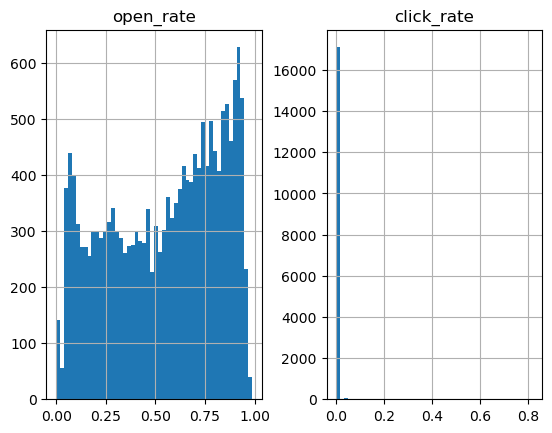

In [67]:
df_user_clean[['open_rate', 'click_rate']].hist(bins=50)

In [68]:
# click rate quantile check
df_user_clean['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500    0.000000
0.750    0.000000
0.900    0.000000
0.950    0.000000
0.990    0.036145
0.999    0.281250
Name: click_rate, dtype: float64

##### Insights
- 95% of users NEVER click
- Top 1% is small clickers (3.61% click rate)
- Top 0.1% is heavy clickers (28.13% click rate)

In [69]:
# click rate quantile check for users who DO click
df_user_clean[df_user_clean['click_rate'] > 0]['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99])

0.50    0.065217
0.75    0.156076
0.90    0.280903
0.95    0.321452
0.99    0.369069
Name: click_rate, dtype: float64

##### Insights
- Higher click rates mmong people who DO click
- Clickers are quite engaged once they exist
- Click is a rare but strong signal

In [70]:
print('% of users who ever click:', (df_user_clean['click_rate'] > 0).mean())

% of users who ever click: 0.010528751590882795


#### Classify users into engagment segmentation

In [71]:
# threshold for high and low engagement
open_threshold = df_user_clean['open_rate'].median()        #median because open rate is reasonably spread, but not symmetric

heavy_click_threshold = df_user_clean['click_rate'].quantile(0.99)

In [72]:
df_user_clean = df_user.dropna(subset=['open_rate', 'click_rate']).copy()

In [73]:
# create user segment

# open segment
df_user_clean['open_segment'] = np.where(
    df_user_clean['open_rate'] >= open_threshold,
    'high_open',
    'low_open')

# click segment
def classify_click(x):
    if x == 0:
        return 'no_click'
    else:
        return 'click'
    
df_user_clean['click_segment'] = df_user_clean['click_rate'].apply(classify_click)

In [74]:
# segment size
df_user_clean.groupby(['open_segment', 'click_segment']).size()

open_segment  click_segment
high_open     click              42
              no_click         8601
low_open      click             140
              no_click         8503
dtype: int64

##### Insights
- Most users frequently open emails
- Only a very small porportion proceed to click
- Users with lower open rates have higher click rates -> selective engagement may indicate stronger intent

### Gender Analysis

In [75]:
df_user_clean.groupby(
    ['open_segment', 'click_segment'])['gender'].value_counts(normalize = True)

open_segment  click_segment  gender
high_open     click          male      0.761905
                             female    0.214286
                             other     0.023810
              no_click       female    0.560865
                             male      0.417393
                             other     0.021742
low_open      click          male      0.514286
                             female    0.485714
              no_click       female    0.559214
                             male      0.420440
                             other     0.020346
Name: proportion, dtype: float64

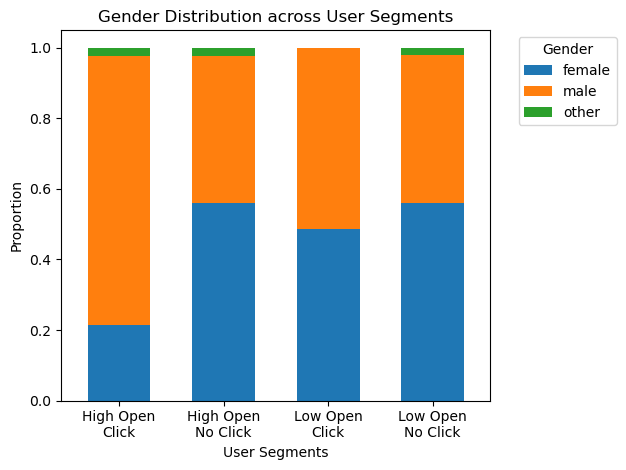

In [76]:
# bar chart

# data prep
gender_distribution = df_user_clean.groupby(
    ['open_segment','click_segment','gender']).size().unstack(fill_value = 0)

# convert to proportions
gender_distribution = gender_distribution.div(gender_distribution.sum(axis = 1), axis = 0)

# plot
gender_distribution.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(gender_distribution.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Gender Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Gender', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

##### Insights
- Male users are more likely to click (strongest in high open high click, with 76% male)
- Female users are more common in non clicking segment
- Conclusion: male users are more likely to convert from opening to clicking

### Age Analysis

In [77]:
df_user_clean.columns

Index(['user_id', 'open_rate', 'click_rate', 'total_emails', 'gender', 'age',
       'interests', 'open_segment', 'click_segment'],
      dtype='object')

In [78]:
# remove unrealistic age
df_user_clean['age_clean'] = df_user_clean['age'].where(
    (df_user_clean['age'] >= 18) &
    (df_user_clean['age'] <= 90))

##### Remark
Unrealistic age values (outside the range 18-90) were removed to ensure data quality

In [79]:
# create age group
df_user_clean['age_group'] = pd.cut(
    df_user_clean['age_clean'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

# count users per age group
df_user_clean['age_group'].value_counts(normalize = True)

age_group
35-50    0.340204
50-65    0.289040
65+      0.206838
18-35    0.163919
Name: proportion, dtype: float64

#### Engagement rate for age groups

In [80]:
# engagement rate for age groups
df_user_clean.groupby('age_group', observed = True)[['open_rate', 'click_rate']].mean()

,open_rate,click_rate
age_group,,
18-35,0.615476,0.000000
35-50,0.568690,0.000107
50-65,0.464278,0.001639
65+,0.430705,0.003304


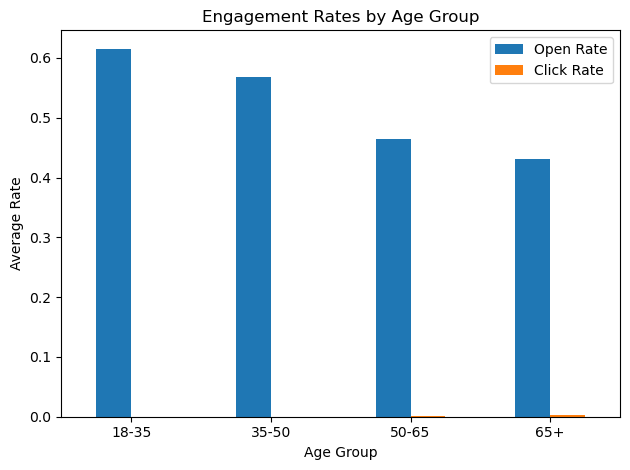

In [81]:
# bar chart

# data prep
age_rates = df_user_clean.groupby('age_group', observed=True)[['open_rate', 'click_rate']].mean()

#plot
age_rates.plot(kind='bar')

plt.title('Engagement Rates by Age Group')
plt.ylabel('Average Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(['Open Rate', 'Click Rate'])
plt.tight_layout()
plt.show()

##### Insights
- Younger users (18-35) have the highest open rate, but rarely click
- Older users (50+) have lower open rate, but more likely to click after opening
- Open rate decrease with age
- Click rate increases with age

#### Age groups vs Engagement segmentation

In [82]:
# age segment size
age_segment = pd.crosstab(
    df_user_clean['age_group'],
    [df_user_clean['open_segment'], df_user_clean['click_segment']],
    normalize = 'index')

age_segment

open_segment  high_open            low_open          
click_segment     click  no_click     click  no_click
age_group                                            
18-35          0.000000  0.624260  0.000000  0.375740
35-50          0.000713  0.521026  0.002138  0.476123
50-65          0.001678  0.378356  0.012584  0.607383
65+            0.008206  0.325909  0.028136  0.637749

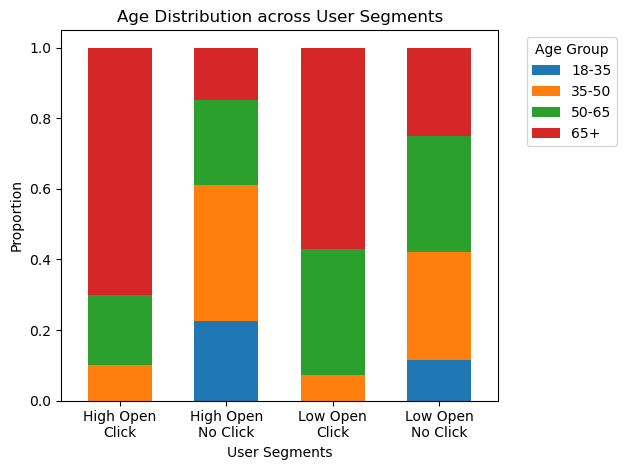

In [83]:
df_user_clean['combined_segment'] = (
    df_user_clean['open_segment'] + ' & ' + df_user_clean['click_segment'])

age_by_segment = pd.crosstab(
    df_user_clean['combined_segment'],
    df_user_clean['age_group'],
    normalize = 'index')

# plot
age_by_segment.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(age_by_segment.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Age Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##### Insights
- Older users (50+) are more likely to click than younger users
- Younger users (18-35) almost never click (regardless of open level)

### Interest Analysis

#### Explore top interests among users

In [84]:
# explode data with interests
df_interests = df_user_clean.copy()
df_interests = df_interests.explode('interests')

In [85]:
# top user interests
top_interests = df_interests['interests'].value_counts().head(10)
print(top_interests)

interests
bladen         17115
acties         16890
kranten        16738
winactie       16167
cadeau         16060
kortingen      16056
energie        15522
goededoelen    14345
onderzoek      14124
auto           11837
Name: count, dtype: int64


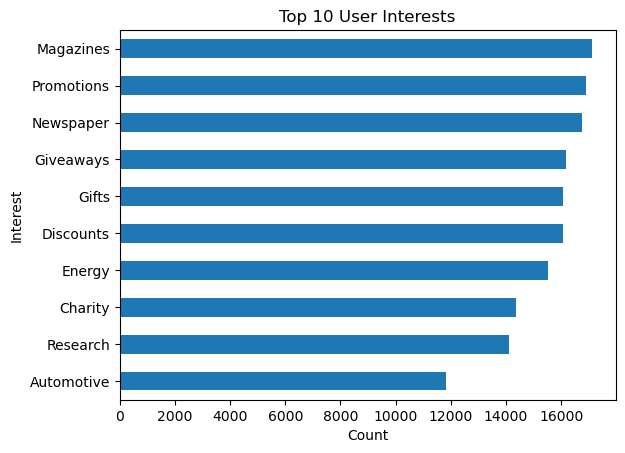

In [86]:
# bar chart

# english translation
interest_map = {
    'bladen': 'Magazines',
    'acties': 'Promotions',
    'kranten': 'Newspaper',
    'winactie': 'Giveaways',
    'cadeau': 'Gifts',
    'kortingen': 'Discounts',
    'energie': 'Energy',
    'goededoelen': 'Charity',
    'onderzoek': 'Research',
    'auto': 'Automotive'}

top_interests_en = top_interests.rename(index = interest_map)

#plot
top_interests_en.plot(kind='barh')
plt.title('Top 10 User Interests')
plt.xlabel('Count')
plt.ylabel('Interest')
plt.gca().invert_yaxis()
plt.show()

##### Insights
- Promotional interests dominate user preferences (promotions, giveaways, gifts, discounts)
- Users show strong interests in informational content (magazines, newspaper, research)
- Commercial topics are also significant (energy and automotive)

#### Explore interests with high engagment rates

In [87]:
# aggregate engagement per interest
interest_engagement = df_interests.groupby('interests').agg(
    open_mean=('open_rate', 'mean'),
    click_mean=('click_rate', 'mean'),
    count=('user_id', 'count'))

interest_engagement.head()

,open_mean,click_mean,count
interests,,,
acties,0.551747,0.001207,16890
android,0.289489,0.001972,1328
audi,0.631697,0.000649,9299
auto,0.574323,0.000851,11837
auto inruilen,0.614763,0.000875,9740


In [88]:
interest_counts = df_interests['interests'].value_counts()
interest_counts.describe()

count       60.000000
mean      6146.933333
std       5542.869329
min          1.000000
25%        723.500000
50%       5429.500000
75%      10089.000000
max      17115.000000
Name: count, dtype: float64

In [89]:
# remove small counts

#threshold for counts
count_threshold = threshold = df_interests['interests'].value_counts().quantile(0.25)
interest_filtered = interest_engagement[
    interest_engagement['count'] >= count_threshold]

##### Remark
Interests with low counts (bottom 25%) to avoid unreliable estimates

In [90]:
# sort interests by open rates
interest_filtered.sort_values('open_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
bezorgmaaltijden,0.753736,0.000156,1806
mazda6e,0.674259,0.001288,4399
finance,0.661999,0.000579,7736
verzekering,0.660851,0.000921,6583
beleggen,0.659138,0.000777,7154
bank,0.648134,0.000579,7270
mercedes,0.648010,0.001059,2704
hypotheek,0.642729,0.000072,1516
bedrijfswagen,0.637129,0.000845,1459


In [91]:
# sort interests by click rates
interest_filtered.sort_values('click_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
windows,0.342804,0.002584,2009
android,0.289489,0.001972,1328
mazda6e,0.674259,0.001288,4399
goededoelen,0.566153,0.001282,14345
acties,0.551747,0.001207,16890
bladen,0.547079,0.001195,17115
ondernemers,0.626589,0.001139,5659
mercedes,0.648010,0.001059,2704
bedrijven,0.571938,0.001017,2413


Some overlap between popular and interests with high engagement, but the relationship is not strong or consistent